# Laboratorio 4: Análisis de Datos GeoEspaciales

CC3084 – Data Science

Iris Ayala - Anggie Quezada - Jonathan Diaz

Análisis de la proliferación de cianobacteria en los lagos de Atitlán y Amatitlán usando imágenes Sentinel-2.

## Librerías

In [1]:
import os
import time
import openeo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import date, timedelta
from dotenv import load_dotenv
from sentinelhub import SHConfig, SentinelHubRequest, SentinelHubSession, DataCollection, MimeType, CRS, BBox, bbox_to_dimensions

## 1. Conexión con la API de Sentinel-2

In [2]:
connection = openeo.connect("https://openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


## 2. Obtención de los datos raster

### Coordenadas de los lagos

In [3]:
lago_atitlan = {
    "west": -91.326256,
    "east": -91.07151,
    "south": 14.5948,
    "north": 14.750979
}

lago_amatitlan = {
    "west": -90.638065,
    "east": -90.512924,
    "south": 14.412347,
    "north": 14.493799
}

### Fechas oficiales por lago

In [4]:
fechas_atitlan = [
    "2025-01-18", "2025-04-13", "2025-05-13", "2025-07-17", "2025-11-21",
    "2025-12-29", "2026-02-12", "2026-03-24", "2026-04-13", "2026-04-28", "2026-07-22"
]

fechas_amatitlan = [
    "2025-01-28", "2025-04-15", "2025-04-28", "2025-11-24", "2026-01-08",
    "2026-02-02", "2026-02-07", "2026-03-29", "2026-04-13", "2026-04-28", "2026-06-19"
]

### Configuración de Sentinel Hub

In [5]:
load_dotenv()

config = SHConfig()
config.sh_client_id = os.environ["SH_CLIENT_ID"]
config.sh_client_secret = os.environ["SH_CLIENT_SECRET"]
config.sh_base_url = "https://sh.dataspace.copernicus.eu"
config.sh_token_url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"

coleccion_s2 = DataCollection.SENTINEL2_L2A.define_from("coleccion_s2", service_url=config.sh_base_url)

### Descarga de bandas

Se descargan únicamente las bandas B03, B04 y B08, necesarias para calcular NDVI y NDWI.

In [6]:
evalscript_bandas = """
//VERSION=3
function setup() {
  return {
    input: ["B03", "B04", "B08"],
    output: { bands: 3, sampleType: "UINT16" }
  };
}
function evaluatePixel(s) {
  return [s.B03, s.B04, s.B08];
}
"""

In [7]:
def descargar_bandas(bbox_dict, fecha, intentos=3):
    bbox = BBox(bbox=[bbox_dict["west"], bbox_dict["south"], bbox_dict["east"], bbox_dict["north"]], crs=CRS.WGS84)
    tamano = bbox_to_dimensions(bbox, resolution=20)
    solicitud = SentinelHubRequest(
        evalscript=evalscript_bandas,
        input_data=[
            SentinelHubRequest.input_data(
                data_collection=coleccion_s2,
                time_interval=(fecha, fecha)
            )
        ],
        responses=[SentinelHubRequest.output_response("default", MimeType.TIFF)],
        bbox=bbox,
        size=tamano,
        config=config
    )
    for intento in range(intentos):
        try:
            return solicitud.get_data()[0]
        except Exception:
            if intento == intentos - 1:
                raise
            SentinelHubSession.clear_cache()
            time.sleep(5)

In [8]:
bandas_atitlan = {fecha: descargar_bandas(lago_atitlan, fecha) for fecha in fechas_atitlan}
bandas_amatitlan = {fecha: descargar_bandas(lago_amatitlan, fecha) for fecha in fechas_amatitlan}

### Verificación de una imagen descargada

In [9]:
print("Dimensiones:", bandas_atitlan[fechas_atitlan[0]].shape)

Dimensiones: (875, 1365, 3)


**Interpretación**

Las dimensiones obtenidas corresponden al recorte del área de cada lago a una resolución de 20 metros por pixel, con 3 bandas (B03, B04, B08). El tamaño coincide con lo esperado para el tamaño geográfico de cada lago.

## 3. Índice de cianobacteria, NDVI y NDWI

### 3.1 Script de detección de cianobacteria

Se usa el script "Cyanobacteria Chlorophyll-a NDCI L1C" de https://custom-scripts.sentinel-hub.com. El script original devuelve un color RGB para visualizar la floración. Se adapta la salida para que devuelva el valor numérico de clorofila-a (`chl`) en lugar del color, manteniendo la misma lógica de detección de agua y el mismo modelo NDCI, ya que el análisis temporal y de correlación (Ejercicio 4) necesita valores numéricos.

Valores de salida:
- `0`: pixel que no es agua.
- `-1`: agua con floración superficial detectada (índice de vegetación flotante alto).
- cualquier otro valor: estimado de clorofila-a (proxy de cianobacteria).

In [10]:
evalscript_cianobacteria = """
//VERSION=3
function setup() {
  return {
    input: ["B02", "B03", "B04", "B05", "B07", "B08", "B8A", "B11", "B12"],
    output: { bands: 1, sampleType: "FLOAT32" }
  };
}

var MNDWI_threshold = 0.42;
var NDWI_threshold = 0.4;
var filter_UABS = true;

function wbi(r, g, b, nir, swir1, swir2) {
  let ws = 0;
  try {
    var ndvi = (nir - r) / (nir + r);
    var mndwi = (g - swir1) / (g + swir1);
    var ndwi = (g - nir) / (g + nir);
    var ndwi_leaves = (nir - swir1) / (nir + swir1);
    var aweish = b + 2.5 * g - 1.5 * (nir + swir1) - 0.25 * swir2;
    var aweinsh = 4 * (g - swir1) - (0.25 * nir + 2.75 * swir1);
    var dbsi = ((swir1 - g) / (swir1 + g)) - ndvi;
    if (mndwi > MNDWI_threshold || ndwi > NDWI_threshold || aweinsh > 0.1879 || aweish > 0.1112 || ndvi < -0.2 || ndwi_leaves > 1) {
      ws = 1;
    }
    if (filter_UABS && ws == 1) {
      if (aweinsh <= -0.03 || dbsi > 0) { ws = 0; }
    }
  } catch (err) { ws = 0; }
  return ws;
}

function FAI(a, b, c) {
  return (b - a - (c - a) * (783 - 665) / (865 - 665));
}

function NDCI(a, b) {
  return (b - a) / (b + a);
}

function evaluatePixel(s) {
  let water = wbi(s.B04, s.B03, s.B02, s.B08, s.B11, s.B12);
  if (water == 0) { return [0]; }

  let FAIv = FAI(s.B04, s.B07, s.B8A);
  if (FAIv > 0.08) { return [-1]; }

  let NDCIv = NDCI(s.B04, s.B05);
  let chl = 826.57 * Math.pow(NDCIv, 3) - 176.43 * Math.pow(NDCIv, 2) + 19 * NDCIv + 4.071;
  return [chl];
}
"""

### 3.2 Función para obtener el índice de cianobacteria

In [11]:
def obtener_indice_cianobacteria(bbox_dict, fecha, intentos=3):
    bbox = BBox(bbox=[bbox_dict["west"], bbox_dict["south"], bbox_dict["east"], bbox_dict["north"]], crs=CRS.WGS84)
    tamano = bbox_to_dimensions(bbox, resolution=20)
    solicitud = SentinelHubRequest(
        evalscript=evalscript_cianobacteria,
        input_data=[
            SentinelHubRequest.input_data(
                data_collection=coleccion_s2,
                time_interval=(fecha, fecha)
            )
        ],
        responses=[SentinelHubRequest.output_response("default", MimeType.TIFF)],
        bbox=bbox,
        size=tamano,
        config=config
    )
    for intento in range(intentos):
        try:
            return solicitud.get_data()[0]
        except Exception:
            if intento == intentos - 1:
                raise
            SentinelHubSession.clear_cache()
            time.sleep(5)

### Cálculo de NDVI y NDWI a partir de las bandas descargadas

In [12]:
def calcular_ndvi_ndwi(bandas_arr):
    green = bandas_arr[:, :, 0].astype(np.float32) / 10000
    red = bandas_arr[:, :, 1].astype(np.float32) / 10000
    nir = bandas_arr[:, :, 2].astype(np.float32) / 10000
    with np.errstate(divide="ignore", invalid="ignore"):
        ndvi = np.where((nir + red) == 0, 0, (nir - red) / (nir + red))
        ndwi = np.where((green + nir) == 0, 0, (green - nir) / (green + nir))
    ndvi = np.nan_to_num(ndvi, nan=0.0)
    ndwi = np.nan_to_num(ndwi, nan=0.0)
    return ndvi, ndwi

### Cálculo para todas las fechas de cada lago

In [13]:
resultados_atitlan = {}
for fecha in fechas_atitlan:
    ndvi, ndwi = calcular_ndvi_ndwi(bandas_atitlan[fecha])
    cianobacteria = obtener_indice_cianobacteria(lago_atitlan, fecha)
    resultados_atitlan[fecha] = {"ndvi": ndvi, "ndwi": ndwi, "cianobacteria": cianobacteria}

In [14]:
resultados_amatitlan = {}
for fecha in fechas_amatitlan:
    ndvi, ndwi = calcular_ndvi_ndwi(bandas_amatitlan[fecha])
    cianobacteria = obtener_indice_cianobacteria(lago_amatitlan, fecha)
    resultados_amatitlan[fecha] = {"ndvi": ndvi, "ndwi": ndwi, "cianobacteria": cianobacteria}

### Visualización del índice de cianobacteria

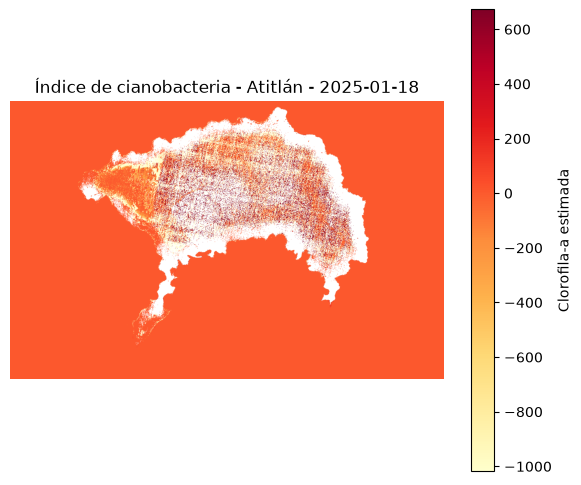

In [15]:
fecha_ejemplo_atitlan = fechas_atitlan[0]
plt.figure(figsize=(7, 6))
plt.imshow(resultados_atitlan[fecha_ejemplo_atitlan]["cianobacteria"], cmap="YlOrRd")
plt.title(f"Índice de cianobacteria - Atitlán - {fecha_ejemplo_atitlan}")
plt.colorbar(label="Clorofila-a estimada")
plt.axis("off")
plt.show()

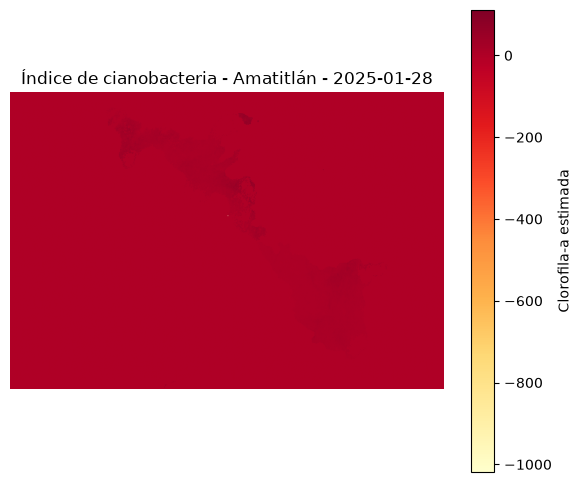

In [16]:
fecha_ejemplo_amatitlan = fechas_amatitlan[0]
plt.figure(figsize=(7, 6))
plt.imshow(resultados_amatitlan[fecha_ejemplo_amatitlan]["cianobacteria"], cmap="YlOrRd")
plt.title(f"Índice de cianobacteria - Amatitlán - {fecha_ejemplo_amatitlan}")
plt.colorbar(label="Clorofila-a estimada")
plt.axis("off")
plt.show()

## 4. Análisis temporal

### 4.1 Índice promedio de cianobacteria por lago y por fecha

In [17]:
def promedio_cianobacteria(arr):
    valido = arr[arr > 0]
    if valido.size == 0:
        return np.nan
    return np.nanmean(valido)

In [18]:
promedio_atitlan = {fecha: promedio_cianobacteria(resultados_atitlan[fecha]["cianobacteria"]) for fecha in fechas_atitlan}

df_atitlan = pd.DataFrame(list(promedio_atitlan.items()), columns=["fecha", "cianobacteria_promedio"])
df_atitlan["fecha"] = pd.to_datetime(df_atitlan["fecha"])
df_atitlan = df_atitlan.sort_values("fecha").reset_index(drop=True)
df_atitlan

,fecha,cianobacteria_promedio
0,2025-01-18,381.082611
1,2025-04-13,3.229907
2,2025-05-13,3.622993
3,2025-07-17,4.240981
4,2025-11-21,7.468000
5,2025-12-29,4.948601
6,2026-02-12,6.826056
7,2026-03-24,3.672394
8,2026-04-13,3.552755
9,2026-04-28,3.138311


In [19]:
promedio_amatitlan = {fecha: promedio_cianobacteria(resultados_amatitlan[fecha]["cianobacteria"]) for fecha in fechas_amatitlan}

df_amatitlan = pd.DataFrame(list(promedio_amatitlan.items()), columns=["fecha", "cianobacteria_promedio"])
df_amatitlan["fecha"] = pd.to_datetime(df_amatitlan["fecha"])
df_amatitlan = df_amatitlan.sort_values("fecha").reset_index(drop=True)
df_amatitlan

,fecha,cianobacteria_promedio
0,2025-01-28,14.914059
1,2025-04-15,10.446157
2,2025-04-28,13.599401
3,2025-11-24,13.132152
4,2026-01-08,23.132414
5,2026-02-02,6.898146
6,2026-02-07,8.121027
7,2026-03-29,17.208698
8,2026-04-13,16.572437
9,2026-04-28,24.688444


### 4.2 Evolución temporal

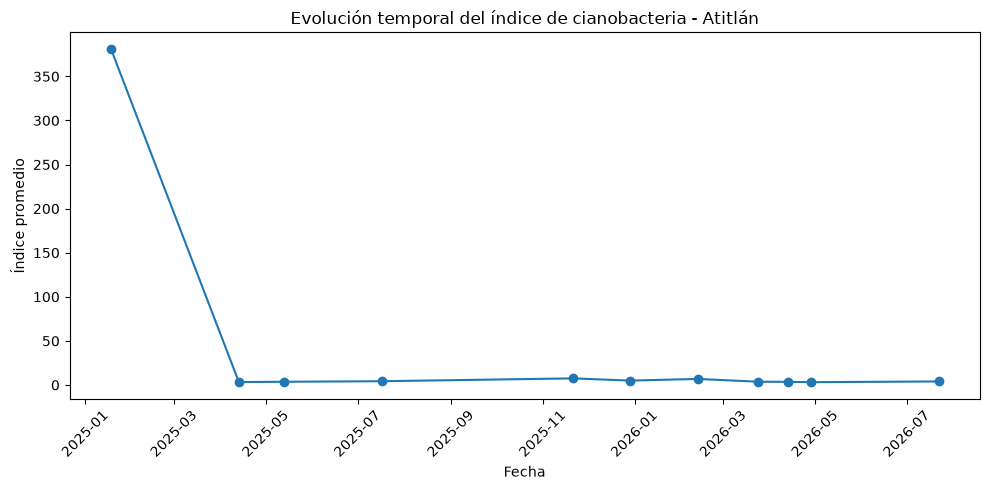

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(df_atitlan["fecha"], df_atitlan["cianobacteria_promedio"], marker="o")
plt.title("Evolución temporal del índice de cianobacteria - Atitlán")
plt.xlabel("Fecha")
plt.ylabel("Índice promedio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

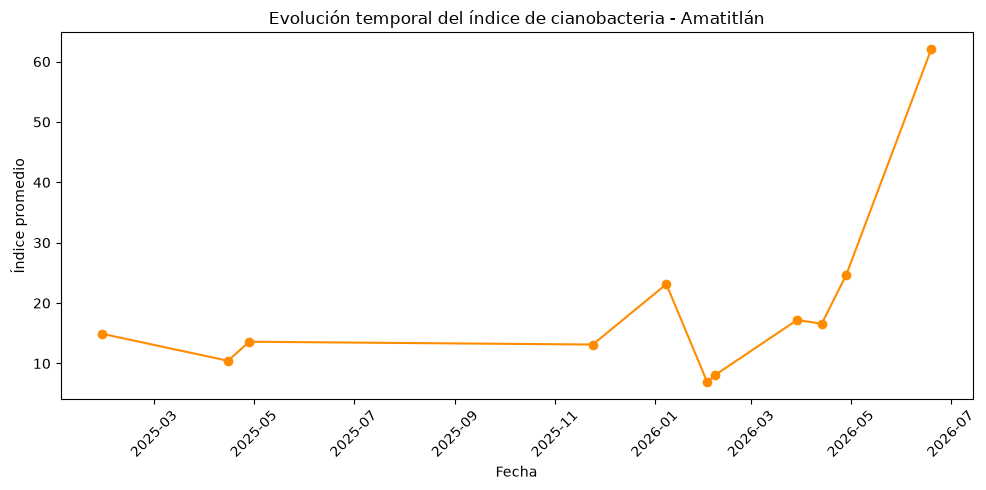

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(df_amatitlan["fecha"], df_amatitlan["cianobacteria_promedio"], marker="o", color="darkorange")
plt.title("Evolución temporal del índice de cianobacteria - Amatitlán")
plt.xlabel("Fecha")
plt.ylabel("Índice promedio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4.3 Picos de floración y fechas críticas

In [22]:
pico_atitlan = df_atitlan.loc[df_atitlan["cianobacteria_promedio"].idxmax()]
pico_amatitlan = df_amatitlan.loc[df_amatitlan["cianobacteria_promedio"].idxmax()]

print("Pico Atitlán:", pico_atitlan["fecha"].date(), "-", round(pico_atitlan["cianobacteria_promedio"], 4))
print("Pico Amatitlán:", pico_amatitlan["fecha"].date(), "-", round(pico_amatitlan["cianobacteria_promedio"], 4))

Pico Atitlán: 2025-01-18 - 381.0826
Pico Amatitlán: 2026-06-19 - 62.0872
